# 🚀 Practice Day 18

**📅 Date:** 2026-09-29  
**📁 Category:** Phase 1 · 시각화 기초 (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice core chart types (bar and line, optionally pie) to compare categories and show trends over time
  (막대·선 그래프(선택적으로 파이차트까지) 기본 차트 유형 연습 — 카테고리 비교와 시간 추이 표현)
- Find which product category drives the most revenue, and which shows the strongest seasonal swing
  (어떤 카테고리가 매출을 가장 많이 견인하는지, 계절 변동이 가장 큰 카테고리는 무엇인지 파악하기)

---
# 📂 Dataset

**Dataset Name:** QuickStop Convenience Store — Monthly Revenue by Category (2024) / QuickStop 편의점 — 카테고리별 월간 매출 (2024)

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** One year (Jan–Dec 2024) of sales for a single convenience store, broken down into 6 product categories (Beverages, Snacks, Ready Meals, Household Items, Dairy, Ice Cream). 72 rows total (6 categories × 12 months), each with units sold and revenue (in USD). The data is clean on purpose — no missing values or duplicates — so the focus stays on choosing and building the right chart for each question.
(단일 편의점 매장의 2024년 1~12월 매출을 6개 상품 카테고리(음료·스낵·즉석식품·생활용품·유제품·아이스크림)로 나눈 월간 데이터입니다. 총 72행(6개 카테고리 × 12개월), 판매수량과 매출액(USD)을 포함합니다. 결측치나 중복 없이 의도적으로 깨끗하게 만들어, 이번 파일의 초점은 질문에 맞는 차트를 직접 고르고 그리는 데 있습니다.)

## Dataset Preview

In [1]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

# --- Generate monthly category sales for a single convenience store (amounts in USD) ---
categories = ['Beverages', 'Snacks', 'Ready Meals', 'Household Items', 'Dairy', 'Ice Cream']
months = pd.date_range('2024-01-01', periods=12, freq='MS')

# Seasonal multiplier per category, one value per month (Jan..Dec)
seasonal = {
    'Beverages':       [0.85, 0.85, 0.9, 0.95, 1.05, 1.2, 1.3, 1.25, 1.05, 0.9, 0.85, 0.9],
    'Snacks':          [0.95, 0.9, 0.95, 0.95, 1.0, 1.0, 1.0, 1.0, 1.0, 1.05, 1.1, 1.3],
    'Ready Meals':     [1.05, 1.05, 1.0, 0.98, 0.95, 0.95, 0.95, 0.95, 0.98, 1.0, 1.05, 1.1],
    'Household Items': [0.95, 0.95, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.05, 1.15],
    'Dairy':           [0.95, 0.95, 1.0, 1.0, 1.0, 1.05, 1.05, 1.0, 1.0, 0.98, 0.98, 1.05],
    'Ice Cream':       [0.35, 0.35, 0.5, 0.7, 1.0, 1.5, 1.8, 1.7, 1.1, 0.6, 0.4, 0.35],
}

# monthly base revenue per category (USD)
base_revenue = {
    'Beverages': 8_000,
    'Snacks': 6_000,
    'Ready Meals': 7_000,
    'Household Items': 3_000,
    'Dairy': 4_000,
    'Ice Cream': 4_500,
}

# average price per unit (USD)
avg_price = {
    'Beverages': 1.80,
    'Snacks': 1.50,
    'Ready Meals': 4.50,
    'Household Items': 6.00,
    'Dairy': 2.80,
    'Ice Cream': 2.00,
}

rows = []
for cat in categories:
    for i, m in enumerate(months):
        noise = np.random.normal(1.0, 0.06)
        revenue = base_revenue[cat] * seasonal[cat][i] * noise
        revenue = int(round(revenue))   # whole dollars
        units = int(round(revenue / avg_price[cat]))
        rows.append({'month': m, 'category': cat, 'units_sold': units, 'revenue': revenue})

df = pd.DataFrame(rows)
df = df.sort_values(['month', 'category']).reset_index(drop=True)

df.head(10)


,month,category,units_sold,revenue
0,2024-01-01,Beverages,3891,7003
1,2024-01-01,Dairy,1385,3878
2,2024-01-01,Household Items,481,2886
3,2024-01-01,Ice Cream,765,1530
4,2024-01-01,Ready Meals,1580,7110
5,2024-01-01,Snacks,3855,5783
6,2024-02-01,Beverages,3747,6744
7,2024-02-01,Dairy,1214,3398
8,2024-02-01,Household Items,419,2515
9,2024-02-01,Ice Cream,778,1557


## Dataset Information

In [2]:
# Dataset Information
df.info()
print("\nShape:", df.shape)
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   month       72 non-null     datetime64[us]
 1   category    72 non-null     str           
 2   units_sold  72 non-null     int64         
 3   revenue     72 non-null     int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 2.4 KB

Shape: (72, 4)


,month,category,units_sold,revenue
count,72,72,72.000000,72.000000
unique,NaN,6,NaN,NaN
top,NaN,Beverages,NaN,NaN
freq,NaN,12,NaN,NaN
mean,2024-06-16 08:00:00,NaN,2320.291667,5324.000000
min,2024-01-01 00:00:00,NaN,419.000000,1530.000000
25%,2024-03-24 06:00:00,NaN,1277.000000,3331.750000
50%,2024-06-16 00:00:00,NaN,1569.500000,5500.000000
75%,2024-09-08 12:00:00,NaN,3800.250000,7006.000000
max,2024-12-01 00:00:00,NaN,6325.000000,11385.000000


---
# ❓ Business Questions

1. **(Analysis)** Which category generated the highest total revenue over the year, and which generated the lowest?
   (연간 총매출 기준 최고·최저 카테고리는 각각 무엇인가?)
2. **(Analysis)** Which category's monthly revenue swings the most across the year, and what does that pattern look like month to month?
   (연중 월별 매출 변동이 가장 큰 카테고리는 어디이며, 그 패턴은 어떤 모습인가?)
3. **(Analysis)** What percentage of total annual revenue does each category contribute?
   (카테고리별 연간 매출 비중은 각각 몇 %인가?)
4. **(Visualization)** How do the categories compare when you look at total revenue side by side?
   (카테고리별 총매출을 나란히 비교하면 어떻게 보이는가?)
5. **(Visualization)** How does each category's revenue move month by month across the year?
   (카테고리별 매출이 월별로 어떻게 변화하는가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `groupby().agg()`, `pivot`, `sort_values`
  (그룹별 집계, 피벗, 정렬)
- [ ] SQL
- [x] Matplotlib — `plt.subplots`, `ax.bar`, `ax.pie`, `ax.plot`
  (한 그림에 여러 칸, 막대·파이·선 그래프)
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — `month` is datetime, `units_sold` and `revenue` are int; no fix needed
  (month는 날짜형, units_sold와 revenue는 정수. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [3]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
month         0
category      0
units_sold    0
revenue       0
dtype: int64

Duplicate rows: 0

Dtypes
month         datetime64[us]
category                 str
units_sold             int64
revenue                int64
dtype: object

Column names
['month', 'category', 'units_sold', 'revenue']

Text columns — unique counts
category    6
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** Which category generated the highest total revenue over the year, and which generated the lowest? (연간 총매출 기준 최고·최저 카테고리는?)

**Result:** **Beverages** generated the highest total revenue (**$98,321**), and **Household Items** the lowest (**$35,622**).
(연간 총매출 최고는 Beverages($98,321), 최저는 Household Items($35,622))

**Insight:** Beverages also sold the most units (**54,623**), and Household Items sold the fewest (**5,936**). Ready Meals is second in revenue (**$83,043**) with only **18,453** units, so its revenue per unit is high.
(Beverages는 판매수량도 가장 많고(54,623) Household Items는 가장 적음(5,936). Ready Meals는 매출 2위($83,043)인데 판매수량은 18,453개뿐이라 개당 매출이 높음)

In [4]:
# Question 1: highest and lowest total revenue by category
# Hint: df.groupby('category')['revenue'].sum().sort_values()

df.groupby('category').agg(
    revenue=('revenue', 'sum'),
    units_sold=('units_sold', 'sum'),
    ).sort_values('revenue', ascending=False)

,revenue,units_sold
category,,
Beverages,98321,54623
Ready Meals,83043,18453
Snacks,70597,47064
Dairy,48228,17226
Ice Cream,47517,23759
Household Items,35622,5936


## Question 2

**Question:** Which category's monthly revenue swings the most across the year, and what does that pattern look like month to month? (월별 매출 변동이 가장 큰 카테고리와 그 패턴은?)

**Result:** **Ice Cream** swings the most. Its monthly revenue range is **$6,581**, the standard deviation is **$2,604**, and the coefficient of variation is **65.8%**. All three are the highest. Beverages is second (range **$4,774**, CV **18.6%**). In the line chart, Ice Cream is lowest in January and February (about **$1.5K**), rises from March, peaks in July and August (about **$8.1K**), then drops sharply in September and October.
(변동이 가장 큰 카테고리는 Ice Cream. 월별 매출 범위 $6,581, 표준편차 $2,604, 변동계수 65.8%로 세 기준 모두 1위. 2위는 Beverages(범위 $4,774, 변동계수 18.6%). 선그래프에서 Ice Cream은 1~2월에 가장 낮고(약 $1.5K) 3월부터 올라 7~8월에 정점(약 $8.1K)을 찍고 9~10월에 급하게 떨어짐)

**Insight:** Ice Cream is a strongly summer-driven category: it peaks in the warmest months and falls to its lowest in winter. Ready Meals is the steadiest (CV **6.4%**).
(Ice Cream은 여름에 크게 좌우되는 카테고리로, 가장 더운 달에 정점이고 겨울에 가장 낮음. Ready Meals가 가장 안정적(변동계수 6.4%))

In [5]:
# Question 2: which category has the most month-to-month variation
# Hint: group by category, compare the spread (max-min, or std) of monthly revenue

stats = df.groupby('category')['revenue'].agg(
    range=lambda s: s.max() - s.min(),
    std='std',
    mean='mean'
)

stats[['range', 'std']]

,range,std
category,,
Beverages,4774,1522.374668
Dairy,1062,310.947233
Household Items,1154,278.935150
Ice Cream,6581,2604.160801
Ready Meals,1303,440.917252
Snacks,2353,668.677998


In [6]:
# Coefficient of variation (CV) = std / mean, shown as a percentage
stats['cv_pct'] = (stats['std'] / stats['mean'] * 100).round(1)

stats[['range', 'std', 'mean', 'cv_pct']].sort_values('cv_pct', ascending=False)

,range,std,mean,cv_pct
category,,,,
Ice Cream,6581,2604.160801,3959.750000,65.8
Beverages,4774,1522.374668,8193.416667,18.6
Snacks,2353,668.677998,5883.083333,11.4
Household Items,1154,278.935150,2968.500000,9.4
Dairy,1062,310.947233,4019.000000,7.7
Ready Meals,1303,440.917252,6920.250000,6.4


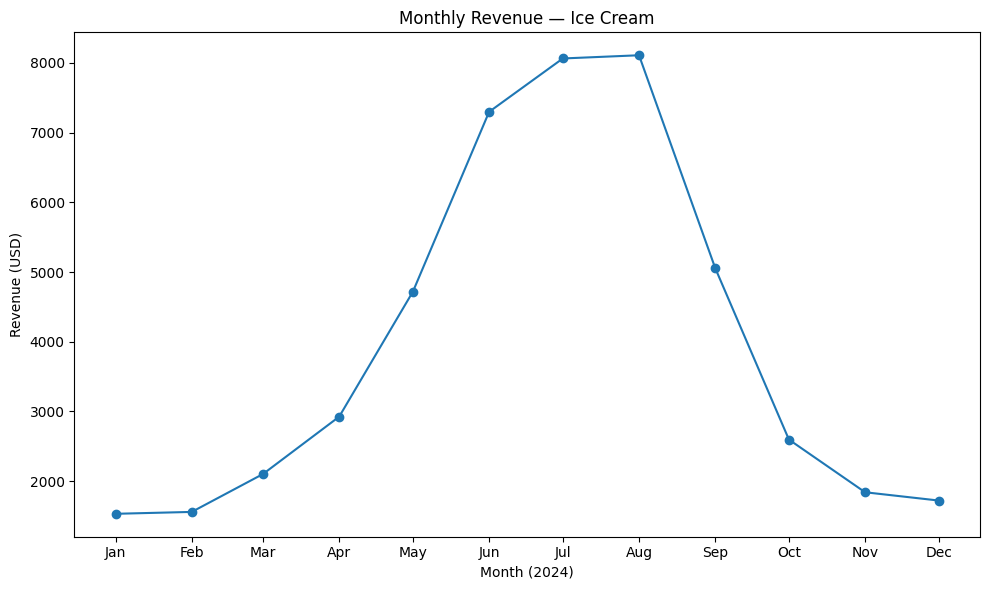

In [7]:
import matplotlib.pyplot as plt

ice_cream = df.pivot(index='month', columns='category', values='revenue')['Ice Cream']

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ice_cream.index, ice_cream.values, marker='o')

ax.set_xticks(ice_cream.index)
ax.set_xticklabels(ice_cream.index.strftime('%b'))

ax.set_xlabel('Month (2024)')
ax.set_ylabel('Revenue (USD)')
ax.set_title('Monthly Revenue — Ice Cream')

plt.tight_layout()
plt.show()

## Question 3

**Question:** What percentage of total annual revenue does each category contribute? (카테고리별 연간 매출 비중은?)

**Result:** Beverages **25.6%**, Ready Meals **21.7%**, Snacks **18.4%**, Dairy **12.6%**, Ice Cream **12.4%**, Household Items **9.3%**.
(Beverages 25.6%, Ready Meals 21.7%, Snacks 18.4%, Dairy 12.6%, Ice Cream 12.4%, Household Items 9.3%)

**Insight:** Beverages, Ready Meals, and Snacks each contribute more than **18%**. Ice Cream swings the most (Q2) but contributes only **12.4%** of annual revenue.
(Beverages, Ready Meals, Snacks가 각각 18% 이상을 차지. Ice Cream은 변동이 가장 크지만(Q2) 연간 매출 비중은 12.4%뿐)

In [8]:
# Question 3: each category's % share of total annual revenue
# Hint: category totals / overall total * 100

share = df.groupby('category')['revenue'].sum() / df['revenue'].sum() * 100
share.round(1).sort_values(ascending=False)

category
Beverages          25.6
Ready Meals        21.7
Snacks             18.4
Dairy              12.6
Ice Cream          12.4
Household Items     9.3
Name: revenue, dtype: float64

---
# 📈 Visualization

**Chart 1:** Bar chart (or pie chart) — total revenue by category (막대그래프 또는 파이차트: 카테고리별 총매출)

*Interpretation:* In the bar chart, Beverages is the tallest (about **$98K**) and Household Items is the shortest (about **$36K**). The pie chart shows the same order: Beverages has the largest slice (**25.6%**) and Household Items the smallest (**9.3%**).
(막대그래프에서 Beverages가 가장 높고(약 $98K) Household Items가 가장 낮음(약 $36K). 파이차트도 같은 순서로 Beverages가 가장 큰 조각(25.6%), Household Items가 가장 작은 조각(9.3%))

---

**Chart 2:** Line chart — monthly revenue trend by category (선그래프: 카테고리별 월별 매출 추이)

*Interpretation:* Ice Cream starts as the lowest line in winter (about **$1.5K**), crosses the other lines around April and May, and reaches about **$8.1K** in July and August before falling back to about **$1.7K** by December. Beverages also peaks in July (about **$11.4K**) and is the top line most of the year. The other categories stay fairly flat across the months.
(Ice Cream은 겨울에 가장 낮은 선(약 $1.5K)에서 시작해 4~5월쯤 다른 선들을 넘고, 7~8월에 약 $8.1K까지 올랐다가 12월에는 약 $1.7K로 내려감. Beverages도 7월에 정점(약 $11.4K)이고 연중 대부분 가장 위의 선. 나머지 카테고리는 월별로 비교적 평평)

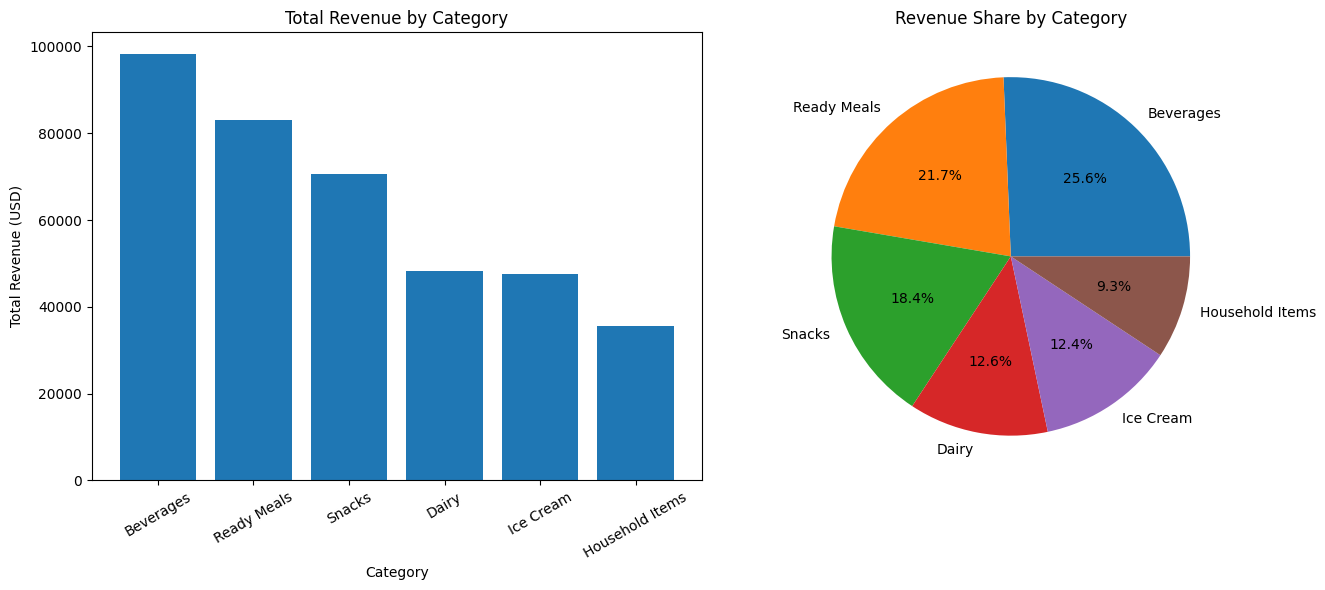

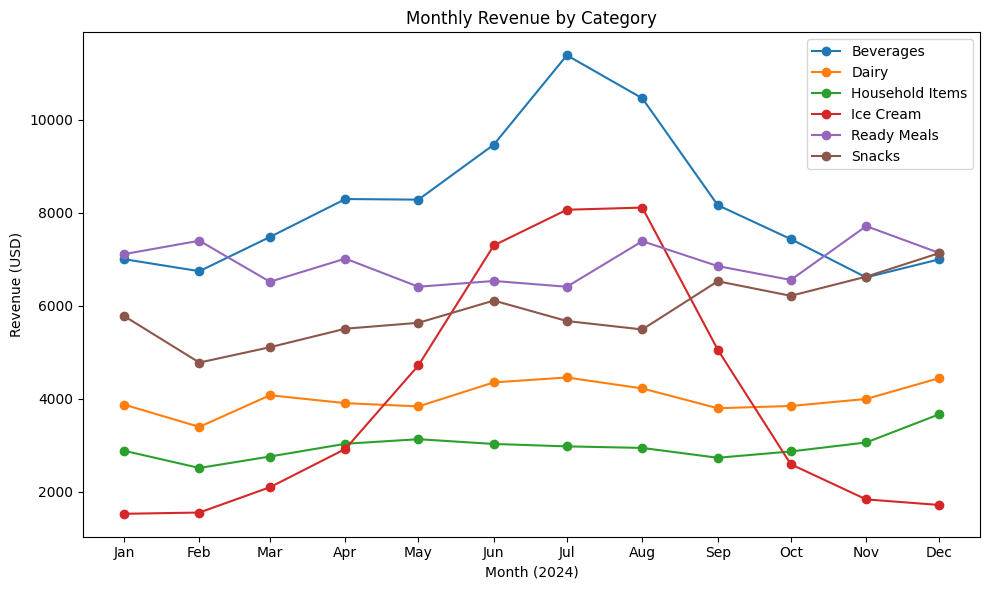

In [9]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: total revenue by category (bar) or each category's share of the total (pie)
totals = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# left: bar
ax1.bar(totals.index, totals.values)
ax1.set_xlabel('Category')
ax1.set_ylabel('Total Revenue (USD)')
ax1.set_title('Total Revenue by Category')
ax1.tick_params(axis='x', rotation=30)

# right: pie
ax2.pie(totals.values, labels=totals.index, autopct='%1.1f%%')
ax2.set_title('Revenue Share by Category')

plt.tight_layout()
plt.show()

# Chart 2: monthly revenue trend, one line per category
pivot = df.pivot(index='month', columns='category', values='revenue')

fig, ax = plt.subplots(figsize=(10, 6))

for cat in pivot.columns:
    ax.plot(pivot.index, pivot[cat], marker='o', label=cat)

ax.set_xticks(pivot.index)
ax.set_xticklabels(pivot.index.strftime('%b'))

ax.set_xlabel('Month (2024)')
ax.set_ylabel('Revenue (USD)')
ax.set_title('Monthly Revenue by Category')
ax.legend()

plt.tight_layout()
plt.show()

---
# 💼 Business Insights
**What did I discover?**

- Beverages is the biggest category (**25.6%** of annual revenue, **$98,321**), and Household Items is the smallest (**9.3%**, **$35,622**).
  (Beverages가 가장 큰 카테고리(연간 매출의 25.6%, $98,321)이고 Household Items가 가장 작음(9.3%, $35,622))
- Ice Cream has by far the largest swing (CV **65.8%**): about **$1.5K** in winter and about **$8.1K** in July and August.
  (Ice Cream은 변동이 압도적으로 큼(변동계수 65.8%): 겨울에 약 $1.5K, 7~8월에 약 $8.1K)
- Beverages also peaks in July (about **$11.4K**), while Ready Meals is the steadiest (CV **6.4%**).
  (Beverages도 7월에 정점(약 $11.4K)이고 Ready Meals가 가장 안정적(변동계수 6.4%))
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Plan Ice Cream stock and freezer space around the summer peak (June to August), and avoid large orders in winter.
   (Ice Cream 재고와 냉동고 공간을 여름 정점(6~8월)에 맞추고, 겨울에는 대량 발주를 피하기)
2. Prepare Beverages for the July peak, because it is both the biggest category and a summer peak.
   (Beverages는 가장 큰 카테고리이면서 여름 정점이므로 7월 성수기에 대비)
3. Treat Ready Meals as a steady base (low swing, second-largest revenue), and test promotions to lift Ice Cream in winter.
   (Ready Meals는 변동이 작고 매출 2위인 안정적인 기반으로 보고, 겨울에 Ice Cream을 끌어올릴 프로모션을 시험)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I plotted `df['category']` and `df['revenue']` directly in the bar chart. That uses all 72 monthly rows, so I needed `groupby().sum()` first to get totals.
  (막대그래프에 df['category']와 df['revenue']를 그대로 넣음. 월별 72행이 그대로 쓰이므로 먼저 groupby().sum()으로 총매출을 구해야 함)
- I passed `label=df['category']` to `ax.plot`. A line needs one name, so I loop over the categories and give each line its own label.
  (ax.plot에 label=df['category']를 넣음. 선 하나에는 이름 하나가 필요하므로 카테고리마다 반복해서 선마다 label을 줌)
- I first compared swings with `std` and `range` only, but categories have different sizes. The coefficient of variation fixes that.
  (처음에는 std와 range만으로 변동을 비교했는데 카테고리마다 규모가 다름. 변동계수로 보완)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- Standard deviation is how far monthly values usually are from that category's own average. Dividing it by the mean (the coefficient of variation) lets me compare categories of different sizes.
  (표준편차는 월별 값이 그 카테고리 자신의 평균에서 보통 얼마나 떨어져 있는지. 평균으로 나눈 변동계수는 규모가 다른 카테고리를 비교하게 해 줌)
- `plt.subplots(1, 2)` puts two charts side by side, and `pivot` plus a loop draws one line per category.
  (plt.subplots(1, 2)로 두 차트를 나란히 놓고, pivot과 반복문으로 카테고리마다 선을 그림)
- A table tells who swings the most, and a line chart tells when it rises and falls.
  (표는 누가 가장 흔들리는지 알려 주고 선그래프는 언제 오르내리는지 알려 줌)
  

---
# 🧠 Reflection

**What was difficult?**
Understanding standard deviation and the coefficient of variation, and reading them from the table.
(표준편차와 변동계수를 이해하고 표에서 읽는 것)

**Why?**
These were new ideas for me, and I did not know which average the standard deviation is measured from.
(처음 접하는 개념이었고 표준편차가 어떤 평균을 기준으로 하는지 몰랐음)

**How did I solve it?**
I learned that it is the category's own average, compared the range, std, and CV columns, and then checked the pattern in the line chart.
(그 카테고리 자신의 평균이 기준이라는 것을 알았고, range, std, 변동계수 열을 비교한 뒤 선그래프로 패턴을 확인)

**What would I do differently next time?**
Check the data scale before comparing categories, and decide the chart data (totals or monthly) before drawing.
(카테고리를 비교하기 전에 데이터의 규모를 확인하고, 그리기 전에 차트용 데이터(총합인지 월별인지)를 먼저 정하기)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
Chart types and `groupby` are clear. Standard deviation and the coefficient of variation needed help.  
(차트 종류와 groupby는 이해. 표준편차와 변동계수는 도움 필요)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★★☆☆☆☆  
Reading standard deviation and the coefficient of variation was the hardest.  
(표준편차와 변동계수를 읽는 것이 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 19 — Pandas GroupBy & Pivot (Round 2/5)
  (Pandas GroupBy & Pivot 복습)
  